In [1]:
# https://huggingface.co/learn/deep-rl-course/unit2/hands-on
# https://gymnasium.farama.org/

import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
import numpy as np

In [3]:
from numpy import random

In [4]:
import imageio
import os

In [5]:
def plot_env(env):
    img = env.render()
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    clear_output(wait=True)
    display(plt.gcf())
    plt.close()

In [6]:
env = gym.make("FrozenLake-v1", map_name="4x4", render_mode="rgb_array", is_slippery=False)
observation, info = env.reset(seed=42)

In [7]:
observation

0

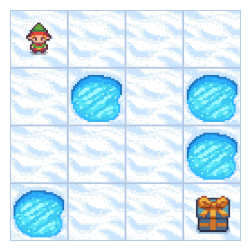

In [8]:
plot_env(env)

In [9]:
print("OBSERVATION SPACE\n")
print("Observation Space", env.observation_space)
print("Sample observation", env.observation_space.sample())

OBSERVATION SPACE

Observation Space Discrete(16)
Sample observation 0


In [10]:
# observation_space means states of env
env.unwrapped.s = 13

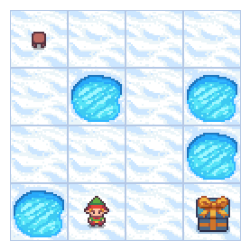

In [11]:
plot_env(env)

In [12]:
print("ACTION SPACE")
print("Action Space Shape", env.action_space.n)
print("Action Space Sample", env.action_space.sample())  # Take a random action 

ACTION SPACE
Action Space Shape 4
Action Space Sample 2


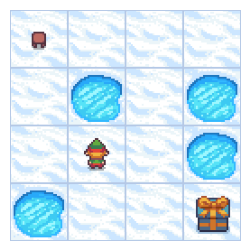

In [13]:
# take action 
action = 3
env.step(action)
plot_env(env)

In [14]:
action = 2
env.step(action)

(10, 0.0, False, False, {'prob': 1.0})

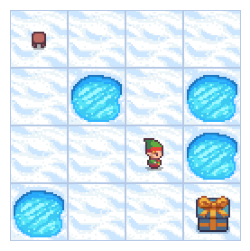

In [15]:
plot_env(env)

In [16]:
action = 1
env.step(action)

(14, 0.0, False, False, {'prob': 1.0})

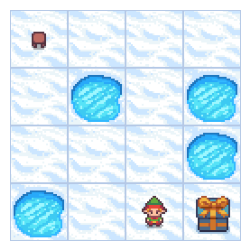

In [17]:
plot_env(env)

In [18]:
action = 0
env.step(action)

(13, 0.0, False, False, {'prob': 1.0})

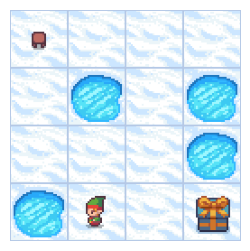

In [19]:
plot_env(env)

In [20]:
env.unwrapped.s = 14

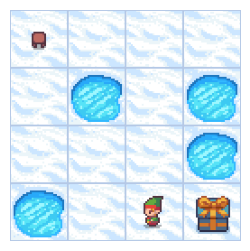

In [21]:
plot_env(env)

In [22]:
action = 2
env.step(action)
# state, reward, terminated, truncated, info = env.step(action)

(15, 1.0, True, False, {'prob': 1.0})

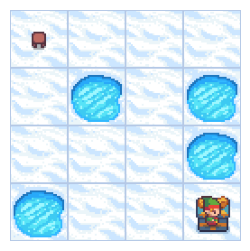

In [23]:
plot_env(env)

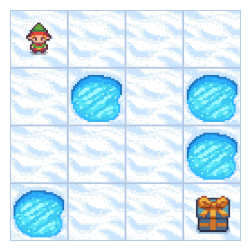

In [24]:
observation, info = env.reset(seed=42)
plot_env(env)

In [25]:
env.step(1)
env.step(2)

(5, 0.0, True, False, {'prob': 1.0})

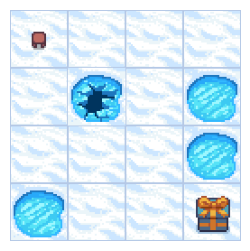

In [26]:
plot_env(env)

In [27]:
# now Q-learning

In [28]:
state_space = env.observation_space.n
print("There are ", state_space, " possible states")

action_space = env.action_space.n
print("There are ", action_space, " possible actions")

There are  16  possible states
There are  4  possible actions


In [29]:
# Let's create our Qtable of size (state_space, action_space) and initialized each values at 0 using np.zeros
def initialize_q_table(state_space, action_space):
    Qtable = np.zeros((state_space, action_space))
    return Qtable

In [30]:
Qtable = initialize_q_table(state_space, action_space)

In [31]:
Qtable

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [32]:
# greedy_policy
def greedy_policy(Qtable, state):
    # Exploitation: take the action with the highest state, action value
    action = np.argmax(Qtable[state][:])

    return action

In [33]:
# epsilon-greedy_policy
def epsilon_greedy_policy(Qtable, state, epsilon):
  # Randomly generate a number between 0 and 1
  random_num = random.uniform(0, 1)
  # if random_num > greater than epsilon --> exploitation
  if random_num > epsilon:
    # Take the action with the highest value given a state
    # np.argmax can be useful here
    action = greedy_policy(Qtable, state)
  # else --> exploration
  else:
    action = env.action_space.sample()

  return action

In [34]:
# Qtable[state][action] = Qtable[state][action] + learning_rate * ( reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

In [35]:
learning_rate = 0.7
gamma = 0.95
epsilon = 0.6
max_step = 99

In [36]:
observation, info = env.reset()

terminated = False      # True when fall in hole or reached goal
truncated = False       # True when actions reach max steps, not set here
state = observation
steps = 0
while not (terminated or truncated):
    action = epsilon_greedy_policy(Qtable, state, epsilon)
    new_state, reward, terminated, truncated, info = env.step(action)

    Qtable[state][action] = Qtable[state][action] + learning_rate * ( reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])
    state = new_state
    steps += 1
    if steps > max_step:
        truncated = True

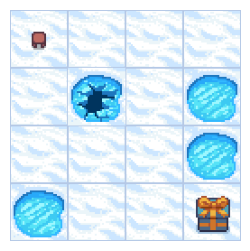

In [37]:
plot_env(env)

In [38]:
# now we want to try 1000 times
# lets try fix epsilon first
n_training_episodes = 1000
epsilon = 0.6

for i in range(n_training_episodes):
    state, info = env.reset()
    
    terminated = False      # True when fall in hole or reached goal
    truncated = False       # True when actions reach max steps, not set here
    steps = 0
    while not (terminated or truncated):
        action = epsilon_greedy_policy(Qtable, state, epsilon)
        new_state, reward, terminated, truncated, info = env.step(action)
        Qtable[state][action] = Qtable[state][action] + learning_rate * ( reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])  
        state = new_state
        steps += 1
        if steps > max_step:
            truncated = True

In [39]:
Qtable

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.7737808 ],
       [0.77378094, 0.857375  , 0.77377926, 0.81450625],
       [0.81450612, 0.        , 0.54164637, 0.        ],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450202],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

In [40]:
obs, info = env.reset()

terminated = False
truncated = False
steps = 0
state = obs
while not (terminated or truncated):
    action = greedy_policy(Qtable, state)
    new_state, reward, terminated, truncated, info = env.step(action)
    state = new_state
    steps += 1
    if steps > max_step:
        truncated = True

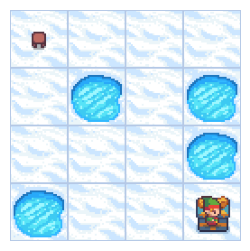

In [41]:
plot_env(env)

In [42]:
Qtable = initialize_q_table(state_space, action_space)

In [43]:
# now we want to try 1000 times
n_training_episodes = 1000
max_epsilon = 1
min_epsilon = 0.05
decay_rate = 0.005

for i in range(n_training_episodes):
    state, info = env.reset()
    
    terminated = False      # True when fall in hole or reached goal
    truncated = False       # True when actions reach max steps, not set here
    steps = 0
    while not (terminated or truncated):
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * i)
        action = epsilon_greedy_policy(Qtable, state, epsilon)
        new_state, reward, terminated, truncated, info = env.step(action)
        Qtable[state][action] = Qtable[state][action] + learning_rate * ( reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])  
        state = new_state
        steps += 1
        if steps > max_step:
            truncated = True

In [44]:
Qtable

array([[0.73509189, 0.77378094, 0.6983373 , 0.73509189],
       [0.73509189, 0.        , 0.68081773, 0.67293418],
       [0.69799633, 0.81760878, 0.        , 0.5879076 ],
       [0.46416756, 0.        , 0.        , 0.        ],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.90249832, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.85733596, 0.95      , 0.        , 0.8572409 ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

In [45]:
obs, info = env.reset()

terminated = False
state = obs
steps = 0
while not (terminated or truncated):
    action = greedy_policy(Qtable, state)
    new_state, reward, terminated, truncated, info = env.step(action)
    state = new_state
    steps += 1
    if steps > max_step:
        truncated = True

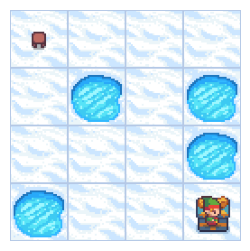

In [46]:
plot_env(env)

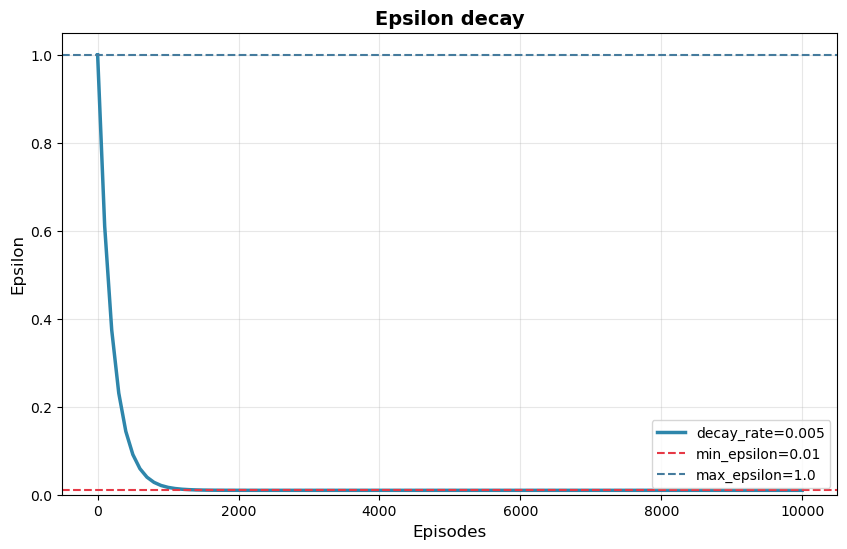

In [47]:
# 最优目标：让 epsilon 在总训练轮次的 70%~80% 左右衰减到 min_epsilon（比如 10000 轮训练，7000~8000 轮时 epsilon 接近 0.01）
import matplotlib.pyplot as plt

# 1. 定义超参数（和你的训练代码一致）
max_epsilon = 1.0    # 初始探索率
min_epsilon = 0.01   # 最小探索率
decay_rate = 0.005   # 衰减率
total_episodes = 10000  # 总训练轮次

# 2. 计算每轮的epsilon值
episodes = np.arange(0, total_episodes + 1, 100)  # 每100轮取一个点（减少计算量）
epsilons = []
for i in episodes:
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * i)
    epsilons.append(epsilon)

# 3. 绘制衰减曲线
plt.figure(figsize=(10, 6))  # 设置画布大小
plt.plot(episodes, epsilons, color='#2E86AB', linewidth=2.5, label=f'decay_rate={decay_rate}')

# 4. 美化图表（添加参考线、标签等）
plt.axhline(y=min_epsilon, color='#E63946', linestyle='--', linewidth=1.5, label=f'min_epsilon={min_epsilon}')
plt.axhline(y=max_epsilon, color='#457B9D', linestyle='--', linewidth=1.5, label=f'max_epsilon={max_epsilon}')
plt.xlabel('Episodes', fontsize=12)
plt.ylabel('Epsilon', fontsize=12)
plt.title('Epsilon decay', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)  # 网格线（透明度0.3，不遮挡曲线）
plt.ylim(0, 1.05)  # y轴范围（0到1.05，更美观）

plt.show()

In [48]:
def train(env, Qtable, n_training_episodes, max_step=99, learning_rate=0.7, gamma=0.95, max_epsilon=1, min_epsilon=0.05, decay_rate = 0.0001):
    for i in range(n_training_episodes):
        state, info = env.reset()
        terminated = False
        truncated = False
        steps = 0
        while not (terminated or truncated):
            epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * i)
            action = epsilon_greedy_policy(Qtable, state, epsilon)
            new_state, reward, terminated, truncated, info = env.step(action)
            Qtable[state][action] = Qtable[state][action] + learning_rate * ( reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])  
            state = new_state  
            steps += 1
            if steps > max_step:
                truncated = True

    return Qtable

In [49]:
Qtable = initialize_q_table(state_space, action_space)
Qtable = train(env, Qtable, n_training_episodes=1000)

In [50]:
Qtable

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.77378093, 0.77378093],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.85737493],
       [0.90249989, 0.94999985, 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

In [51]:
def eval_agent(env, Qtable, n_eval_episodes, seed=42):
    episode_rewards = []
    for i in range(n_eval_episodes):
        state, info = env.reset(seed=seed)
        terminated = False
        truncated = False
        total_reward = 0
        while not (terminated or truncated):
            action = greedy_policy(Qtable, state)
            new_state, reward, terminated, truncated, info = env.step(action)
            state = new_state
            total_reward+=reward
        episode_rewards.append(total_reward)

    return np.mean(episode_rewards)

In [52]:
eval_agent(env, Qtable, n_eval_episodes=1000)

np.float64(1.0)

In [53]:
def save_video(env, Qtable, output_path='example.mp4', fps=1, seed=42):
    images = []
    state, info = env.reset(seed=seed)
    images.append(env.render())
    terminated = False
    truncated = False
    while not (terminated or truncated):
        action = greedy_policy(Qtable, state)
        new_state, reward, terminated, truncated, info = env.step(action)
        state = new_state
        images.append(env.render())
    imageio.mimsave(output_path, images, fps=fps)

In [54]:
save_video(env, Qtable)